In [108]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sahi.models.ultralytics import UltralyticsDetectionModel
from sahi.predict import get_sliced_prediction
from ultralytics import YOLO

model_path = 'runs/detect/train11/weights/best.pt'
model = YOLO(model_path)

model_mask = YOLO('yolo11m-seg.pt')

In [109]:
def get_mask(img: np.ndarray, show: bool) -> np.ndarray | None:
    """
    Uses YOLO-seg to get the mask of a plane in an image.
    Args:
        img (np.ndarray): Image matrix.
        show (bool): Wether to plot the masked image or not
    Returns:
        Masked image (np.ndarray | None): Image matrix with after applying the mask.
    """
    results = model_mask.predict(source=img, retina_masks=True, classes=[4])
    # Si encuentra algo:
    if results[0].masks != None:
        mask = results[0].masks.data[0].cpu().numpy()
        kernel = np.ones((14,14), np.uint8)
        mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)
        cnts, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            mask_solid = np.zeros_like(mask_cleaned)
            cv2.drawContours(mask_solid, [c], -1, 1, thickness=cv2.FILLED)
            mask_cleaned = mask_solid

        img_mask = img.copy()
        img_mask[mask_cleaned==False] = [135,206,235] #Fondo color cielo

        if show:
            plt.imshow(img_mask)
            plt.show()
        return img_mask

In [110]:
def show_results(img: np.ndarray, coords: list[list[float]]) -> None:
    """
    Plots an image with coordinates of the bounding box
    Args:
        img (np.ndarray): Image matrix.
        coords (list[list[float]]): List with the different boxes
    """
    _, ax = plt.subplots(1)
    ax.imshow(img)

    for bbox in coords:
        width = bbox[2] - bbox[0]
        height = bbox[3] - bbox[1]
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), width, height, 
            linewidth=2, edgecolor='r', facecolor='none', label='Avión')
        ax.add_patch(rect)
    plt.show()

In [111]:
def sahi(img: np.ndarray, divisions:float = 3, overlap:float = 0.2) -> list[list[float] ]| None:
    """
    Uses SAHI algorith to pass the model iteratively through smaller square windows of the image (sliding window)
    Args:
        img (np.ndarray): Image matrix.
        divisions (float): Window shape = img.shape[0]/divisions
        overlap (float): Fraction of the window to overlap with the previous one
    Returns:
        Coordinates (list[list[float]] | None): A list of the predicted bounding boxes.
    """
    detection_model = UltralyticsDetectionModel(
    model_path=model_path,
    confidence_threshold=0.25,
    device='cpu')

    result_sahi = get_sliced_prediction(
        img,
        detection_model,
        slice_height=int(img.shape[0]/divisions),
        slice_width=int(img.shape[0]/divisions),
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap)

    num_boxes = len(result_sahi.object_prediction_list)
    print(f"Detectado con SAHI: {num_boxes} objetos")
    if num_boxes == 0: return None

    all_results = []
    for pred_obj in result_sahi.object_prediction_list:
        bbox = pred_obj.bbox
        result = [bbox.minx, bbox.miny, bbox.maxx, bbox.maxy]
        all_results.append(result)

    return all_results


0: 384x640 1 airplane, 862.2ms
Speed: 3.4ms preprocess, 862.2ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)


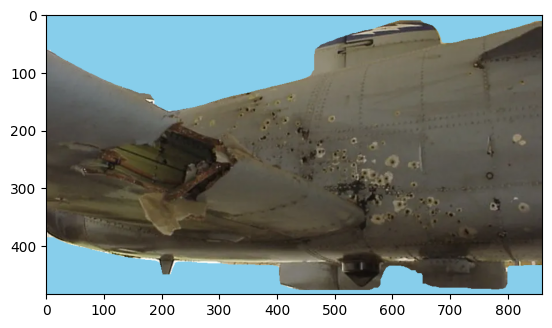


0: 384x640 (no detections), 141.6ms
Speed: 4.9ms preprocess, 141.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
No se ha encontrado nada en la imagen completa. Dividiendo con SAHI...
Performing prediction on 28 slices.
Detectado con SAHI: 4 objetos


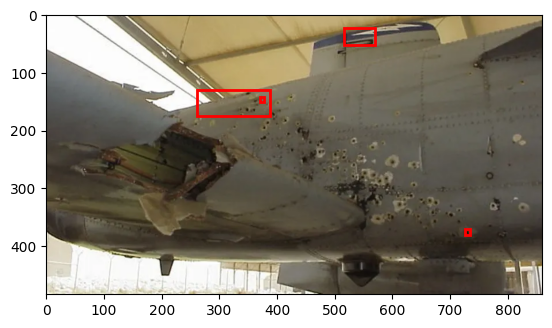

In [112]:
def detect_strike(dir_imagen, show=False, show_mask=False):
    # Leer y aplicar máscara
    img = cv2.imread(dir_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_mask = get_mask(img_rgb, show=show_mask)
    if img_mask is None:
        img_mask = img_rgb
    
    # Intento 1: YOLO Normal (Imagen completa)
    results = model.predict(img_mask, imgsz=640)
    if len(results[0].boxes) != 0: #type: ignore
        all_results = []
        for result in results:
            print("Se han detectado daños con YOLO estándar")
            box = result.boxes.xyxy[0].cpu().numpy() #type: ignore
            all_results.append([box[0], box[1], box[2], box[3]])
        if show:
            show_results(img_rgb, all_results)

    # Intento 2: SAHI (Si YOLO falló)
    else:
        print("No se ha encontrado nada en la imagen completa. Dividiendo con SAHI...")
        coords = sahi(img_mask)
        if coords != None:
            if show: show_results(img_rgb, coords)
        else: print("Ni siquiera SAHI ha encontrado nada.")
        return coords

# Ejecución
dir_imagen = "fotos_prueba/a-10.png"
coords = detect_strike(dir_imagen, show=True, show_mask=True)